# Importing Needed Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.preprocessing import MinMaxScaler

In [2]:
# Read csv files
train = pd.read_csv("/kaggle/input/store-sales-time-series-forecasting/train.csv")
test = pd.read_csv("/kaggle/input/store-sales-time-series-forecasting/test.csv")
stores = pd.read_csv("/kaggle/input/store-sales-time-series-forecasting/stores.csv")
transactions = pd.read_csv("/kaggle/input/store-sales-time-series-forecasting/transactions.csv")
holidays = pd.read_csv("/kaggle/input/store-sales-time-series-forecasting/holidays_events.csv")
oil_price = pd.read_csv("/kaggle/input/store-sales-time-series-forecasting/oil.csv")

In [3]:
import warnings
warnings.filterwarnings("ignore")

# **Train DataSet**

id: Unique identifier for each record.  
date: The date when the sales were recorded.  
store_nbr: Store number where the sales occurred.  
family: Product category or type.  
sales: Total sales revenue (in money) for that date, store, and product family.  
onpromotion: Number of items that were on promotion that day.  

In [4]:
train.columns.tolist()

['id', 'date', 'store_nbr', 'family', 'sales', 'onpromotion']

In [5]:
train.shape

(3000888, 6)

In [6]:
train.head(10)

,id,date,store_nbr,family,sales,onpromotion
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0
1,1,2013-01-01,1,BABY CARE,0.0,0
2,2,2013-01-01,1,BEAUTY,0.0,0
3,3,2013-01-01,1,BEVERAGES,0.0,0
4,4,2013-01-01,1,BOOKS,0.0,0
5,5,2013-01-01,1,BREAD/BAKERY,0.0,0
6,6,2013-01-01,1,CELEBRATION,0.0,0
7,7,2013-01-01,1,CLEANING,0.0,0
8,8,2013-01-01,1,DAIRY,0.0,0
9,9,2013-01-01,1,DELI,0.0,0


In [7]:
train.tail(10)

,id,date,store_nbr,family,sales,onpromotion
3000878,3000878,2017-08-15,9,MAGAZINES,11.000,0
3000879,3000879,2017-08-15,9,MEATS,449.228,0
3000880,3000880,2017-08-15,9,PERSONAL CARE,522.000,11
3000881,3000881,2017-08-15,9,PET SUPPLIES,6.000,0
3000882,3000882,2017-08-15,9,PLAYERS AND ELECTRONICS,6.000,0
3000883,3000883,2017-08-15,9,POULTRY,438.133,0
3000884,3000884,2017-08-15,9,PREPARED FOODS,154.553,1
3000885,3000885,2017-08-15,9,PRODUCE,2419.729,148
3000886,3000886,2017-08-15,9,SCHOOL AND OFFICE SUPPLIES,121.000,8
3000887,3000887,2017-08-15,9,SEAFOOD,16.000,0


In [8]:
train.sample(15)

,id,date,store_nbr,family,sales,onpromotion
2718188,2718188,2017-03-10,27,FROZEN FOODS,133.00,3
2038492,2038492,2016-02-21,6,HOME AND KITCHEN II,48.00,1
2740440,2740440,2017-03-22,50,LINGERIE,6.00,0
1701595,1701595,2015-08-15,52,HOME AND KITCHEN II,0.00,0
2910577,2910577,2017-06-26,25,EGGS,77.00,0
37762,37762,2013-01-22,19,EGGS,22.00,0
1908877,1908877,2015-12-10,19,PERSONAL CARE,133.00,0
956065,956065,2014-06-22,34,"LIQUOR,WINE,BEER",0.00,0
300511,300511,2013-06-18,40,GROCERY II,7.00,0
121664,121664,2013-03-10,22,PET SUPPLIES,0.00,0


# Descriptive Statistics for Numeric Columns:

In [9]:
train.describe().T

,count,mean,std,min,25%,50%,75%,max
id,3000888.0,1.500444e+06,866281.891642,0.0,750221.75,1500443.5,2.250665e+06,3000887.0
store_nbr,3000888.0,2.750000e+01,15.585787,1.0,14.00,27.5,4.100000e+01,54.0
sales,3000888.0,3.577757e+02,1101.997721,0.0,0.00,11.0,1.958473e+02,124717.0
onpromotion,3000888.0,2.602770e+00,12.218882,0.0,0.00,0.0,0.000000e+00,741.0


The dataset has about 3 million records from 54 stores.
Average sales per record are around $358, but most are small (median = $11), showing large variation.
Promotions are rare (median = 0), though some days have many (up to 741).
Overall, sales and promotions show high variability across stores and days.

# Information about Data

In [10]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000888 entries, 0 to 3000887
Data columns (total 6 columns):
 #   Column       Dtype  
---  ------       -----  
 0   id           int64  
 1   date         object 
 2   store_nbr    int64  
 3   family       object 
 4   sales        float64
 5   onpromotion  int64  
dtypes: float64(1), int64(3), object(2)
memory usage: 137.4+ MB


# Checking for Duplicates

In [11]:
train.duplicated().sum()

0

# Checking for Missing Values

In [12]:
train.isnull().sum()

id             0
date           0
store_nbr      0
family         0
sales          0
onpromotion    0
dtype: int64

no null values

In [13]:
train.nunique()

id             3000888
date              1684
store_nbr           54
family              33
sales           379610
onpromotion        362
dtype: int64

### dataset contains 54 stores and 33 type of products


In [14]:
print(train['family'].unique())

['AUTOMOTIVE' 'BABY CARE' 'BEAUTY' 'BEVERAGES' 'BOOKS' 'BREAD/BAKERY'
 'CELEBRATION' 'CLEANING' 'DAIRY' 'DELI' 'EGGS' 'FROZEN FOODS' 'GROCERY I'
 'GROCERY II' 'HARDWARE' 'HOME AND KITCHEN I' 'HOME AND KITCHEN II'
 'HOME APPLIANCES' 'HOME CARE' 'LADIESWEAR' 'LAWN AND GARDEN' 'LINGERIE'
 'LIQUOR,WINE,BEER' 'MAGAZINES' 'MEATS' 'PERSONAL CARE' 'PET SUPPLIES'
 'PLAYERS AND ELECTRONICS' 'POULTRY' 'PREPARED FOODS' 'PRODUCE'
 'SCHOOL AND OFFICE SUPPLIES' 'SEAFOOD']


# Cleaning Text Columns

In [15]:
train['family']=train['family'].str.strip().str.title()

In [16]:
train['date'] = pd.to_datetime(train['date'], format='mixed')

In [17]:
print(train['date'].min(), train['date'].max())

2013-01-01 00:00:00 2017-08-15 00:00:00


In [18]:
train['sales'].describe()

count    3.000888e+06
mean     3.577757e+02
std      1.101998e+03
min      0.000000e+00
25%      0.000000e+00
50%      1.100000e+01
75%      1.958473e+02
max      1.247170e+05
Name: sales, dtype: float64

In [19]:
train.sort_values(by='sales', ascending=False).head(10)

,id,date,store_nbr,family,sales,onpromotion
2163723,2163723,2016-05-02,2,Grocery I,124717.000,59
2445984,2445984,2016-10-07,39,Meats,89576.360,0
2144154,2144154,2016-04-21,20,Grocery I,87438.516,53
2139699,2139699,2016-04-18,45,Grocery I,76090.000,38
2153031,2153031,2016-04-26,2,Grocery I,63434.000,30
2145045,2145045,2016-04-21,45,Grocery I,53874.000,44
562596,562596,2013-11-12,44,Grocery I,46271.000,0
1257246,1257246,2014-12-08,35,Grocery I,45361.000,3
1916586,1916586,2015-12-14,35,Grocery I,40351.460,7
2760297,2760297,2017-04-02,9,Grocery I,38422.625,73


In [20]:
print("\nCounts per family:\n", train['family'].value_counts())


Counts per family:
 family
Automotive                    90936
Home Appliances               90936
School And Office Supplies    90936
Produce                       90936
Prepared Foods                90936
Poultry                       90936
Players And Electronics       90936
Pet Supplies                  90936
Personal Care                 90936
Meats                         90936
Magazines                     90936
Liquor,Wine,Beer              90936
Lingerie                      90936
Lawn And Garden               90936
Ladieswear                    90936
Home Care                     90936
Home And Kitchen Ii           90936
Baby Care                     90936
Home And Kitchen I            90936
Hardware                      90936
Grocery Ii                    90936
Grocery I                     90936
Frozen Foods                  90936
Eggs                          90936
Deli                          90936
Dairy                         90936
Cleaning                      90936


# **Test DataSet**

## DataSet Columns

In [21]:
test.columns.tolist()

['id', 'date', 'store_nbr', 'family', 'onpromotion']

In [22]:
test.shape

(28512, 5)

In [23]:
test.head(10)

,id,date,store_nbr,family,onpromotion
0,3000888,2017-08-16,1,AUTOMOTIVE,0
1,3000889,2017-08-16,1,BABY CARE,0
2,3000890,2017-08-16,1,BEAUTY,2
3,3000891,2017-08-16,1,BEVERAGES,20
4,3000892,2017-08-16,1,BOOKS,0
5,3000893,2017-08-16,1,BREAD/BAKERY,12
6,3000894,2017-08-16,1,CELEBRATION,0
7,3000895,2017-08-16,1,CLEANING,25
8,3000896,2017-08-16,1,DAIRY,45
9,3000897,2017-08-16,1,DELI,18


In [24]:
test.tail(10)

,id,date,store_nbr,family,onpromotion
28502,3029390,2017-08-31,9,MAGAZINES,0
28503,3029391,2017-08-31,9,MEATS,20
28504,3029392,2017-08-31,9,PERSONAL CARE,14
28505,3029393,2017-08-31,9,PET SUPPLIES,0
28506,3029394,2017-08-31,9,PLAYERS AND ELECTRONICS,0
28507,3029395,2017-08-31,9,POULTRY,1
28508,3029396,2017-08-31,9,PREPARED FOODS,0
28509,3029397,2017-08-31,9,PRODUCE,1
28510,3029398,2017-08-31,9,SCHOOL AND OFFICE SUPPLIES,9
28511,3029399,2017-08-31,9,SEAFOOD,0


In [25]:
test.sample(15)

,id,date,store_nbr,family,onpromotion
12521,3013409,2017-08-23,10,HARDWARE,0
19504,3020392,2017-08-26,7,BABY CARE,0
18049,3018937,2017-08-26,15,SCHOOL AND OFFICE SUPPLIES,3
25604,3026492,2017-08-30,27,PREPARED FOODS,0
21316,3022204,2017-08-27,7,SCHOOL AND OFFICE SUPPLIES,0
28208,3029096,2017-08-31,5,PET SUPPLIES,0
14117,3015005,2017-08-23,54,PET SUPPLIES,0
27314,3028202,2017-08-31,25,MAGAZINES,0
546,3001434,2017-08-16,24,HOME CARE,11
22528,3023416,2017-08-28,40,"LIQUOR,WINE,BEER",0


# Information about Data

In [26]:
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28512 entries, 0 to 28511
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   id           28512 non-null  int64 
 1   date         28512 non-null  object
 2   store_nbr    28512 non-null  int64 
 3   family       28512 non-null  object
 4   onpromotion  28512 non-null  int64 
dtypes: int64(3), object(2)
memory usage: 1.1+ MB


# Descriptive Statistics for Numeric Columns

In [27]:
test.describe().T

,count,mean,std,min,25%,50%,75%,max
id,28512.0,3.015144e+06,8230.849774,3000888.0,3008015.75,3015143.5,3022271.25,3029399.0
store_nbr,28512.0,2.750000e+01,15.586057,1.0,14.00,27.5,41.00,54.0
onpromotion,28512.0,6.965383e+00,20.683952,0.0,0.00,0.0,6.00,646.0


# Checking for Duplicates

In [28]:
test.duplicated().sum()

0

# Checking for Missing Values

In [29]:
test.isnull().sum()

id             0
date           0
store_nbr      0
family         0
onpromotion    0
dtype: int64

There are no null values in this data

In [30]:
test.nunique()

id             28512
date              16
store_nbr         54
family            33
onpromotion      212
dtype: int64

In [31]:
test['family'].unique()

array(['AUTOMOTIVE', 'BABY CARE', 'BEAUTY', 'BEVERAGES', 'BOOKS',
       'BREAD/BAKERY', 'CELEBRATION', 'CLEANING', 'DAIRY', 'DELI', 'EGGS',
       'FROZEN FOODS', 'GROCERY I', 'GROCERY II', 'HARDWARE',
       'HOME AND KITCHEN I', 'HOME AND KITCHEN II', 'HOME APPLIANCES',
       'HOME CARE', 'LADIESWEAR', 'LAWN AND GARDEN', 'LINGERIE',
       'LIQUOR,WINE,BEER', 'MAGAZINES', 'MEATS', 'PERSONAL CARE',
       'PET SUPPLIES', 'PLAYERS AND ELECTRONICS', 'POULTRY',
       'PREPARED FOODS', 'PRODUCE', 'SCHOOL AND OFFICE SUPPLIES',
       'SEAFOOD'], dtype=object)

# Cleaning Text Columns

In [32]:
test['family']=test['family'].str.strip().str.title()

# Date Column Transformation

In [33]:
print(test['date'].min(), test['date'].max())

2017-08-16 2017-08-31


In [34]:
test.sample(10)

,id,date,store_nbr,family,onpromotion
17239,3018127,2017-08-25,42,Grocery Ii,0
25093,3025981,2017-08-30,13,Grocery Ii,0
27993,3028881,2017-08-31,44,Deli,11
7705,3008593,2017-08-20,25,Home And Kitchen Ii,0
23561,3024449,2017-08-29,2,Seafood,1
1383,3002271,2017-08-16,47,Produce,256
21551,3022439,2017-08-28,14,Beauty,0
25259,3026147,2017-08-30,18,Hardware,0
10545,3011433,2017-08-21,54,Home Care,7
6347,3007235,2017-08-19,37,Frozen Foods,0


In [35]:
test.describe().T

,count,mean,std,min,25%,50%,75%,max
id,28512.0,3.015144e+06,8230.849774,3000888.0,3008015.75,3015143.5,3022271.25,3029399.0
store_nbr,28512.0,2.750000e+01,15.586057,1.0,14.00,27.5,41.00,54.0
onpromotion,28512.0,6.965383e+00,20.683952,0.0,0.00,0.0,6.00,646.0


# **Holidays Events DataSet**

date: The date of the holiday.

type: The type of the holiday (e.g., Holiday, Transfer, Additional, Bridge, Work Day).

locale: The scope of the holiday (National, Regional, or Local).

locale_name: The specific region or city where the holiday applies.

description: The name or description of the holiday
transferred: Indicates whether the holiday was moved to another date (True or False).

In [36]:
holidays.columns.tolist()

['date', 'type', 'locale', 'locale_name', 'description', 'transferred']

In [37]:
holidays.shape

(350, 6)

In [38]:
holidays.head(10)

,date,type,locale,locale_name,description,transferred
0,2012-03-02,Holiday,Local,Manta,Fundacion de Manta,False
1,2012-04-01,Holiday,Regional,Cotopaxi,Provincializacion de Cotopaxi,False
2,2012-04-12,Holiday,Local,Cuenca,Fundacion de Cuenca,False
3,2012-04-14,Holiday,Local,Libertad,Cantonizacion de Libertad,False
4,2012-04-21,Holiday,Local,Riobamba,Cantonizacion de Riobamba,False
5,2012-05-12,Holiday,Local,Puyo,Cantonizacion del Puyo,False
6,2012-06-23,Holiday,Local,Guaranda,Cantonizacion de Guaranda,False
7,2012-06-25,Holiday,Regional,Imbabura,Provincializacion de Imbabura,False
8,2012-06-25,Holiday,Local,Latacunga,Cantonizacion de Latacunga,False
9,2012-06-25,Holiday,Local,Machala,Fundacion de Machala,False


In [39]:
holidays.tail(10)

,date,type,locale,locale_name,description,transferred
340,2017-12-06,Holiday,Local,Quito,Fundacion de Quito,True
341,2017-12-08,Holiday,Local,Loja,Fundacion de Loja,False
342,2017-12-08,Transfer,Local,Quito,Traslado Fundacion de Quito,False
343,2017-12-21,Additional,National,Ecuador,Navidad-4,False
344,2017-12-22,Holiday,Local,Salinas,Cantonizacion de Salinas,False
345,2017-12-22,Additional,National,Ecuador,Navidad-3,False
346,2017-12-23,Additional,National,Ecuador,Navidad-2,False
347,2017-12-24,Additional,National,Ecuador,Navidad-1,False
348,2017-12-25,Holiday,National,Ecuador,Navidad,False
349,2017-12-26,Additional,National,Ecuador,Navidad+1,False


In [40]:
holidays.sample(15)

,date,type,locale,locale_name,description,transferred
242,2016-05-07,Additional,National,Ecuador,Dia de la Madre-1,False
15,2012-08-15,Holiday,Local,Riobamba,Fundacion de Riobamba,False
1,2012-04-01,Holiday,Regional,Cotopaxi,Provincializacion de Cotopaxi,False
165,2015-04-01,Holiday,Regional,Cotopaxi,Provincializacion de Cotopaxi,False
258,2016-06-25,Holiday,Local,Machala,Fundacion de Machala,False
167,2015-04-12,Holiday,Local,Cuenca,Fundacion de Cuenca,False
50,2013-04-21,Holiday,Local,Riobamba,Cantonizacion de Riobamba,False
287,2016-12-06,Holiday,Local,Quito,Fundacion de Quito,False
284,2016-11-25,Event,National,Ecuador,Black Friday,False
265,2016-07-24,Transfer,Local,Guayaquil,Traslado Fundacion de Guayaquil,False


# Showing Information about DataSet

In [41]:
holidays.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 350 entries, 0 to 349
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   date         350 non-null    object
 1   type         350 non-null    object
 2   locale       350 non-null    object
 3   locale_name  350 non-null    object
 4   description  350 non-null    object
 5   transferred  350 non-null    bool  
dtypes: bool(1), object(5)
memory usage: 14.1+ KB


# Descriptive Statistics for Columns

In [42]:
holidays.describe().T

,count,unique,top,freq
date,350,312,2014-06-25,4
type,350,6,Holiday,221
locale,350,3,National,174
locale_name,350,24,Ecuador,174
description,350,103,Carnaval,10
transferred,350,2,False,338


# Checking for Duplicates

In [43]:
holidays.duplicated().sum()

0

# Checking for Missing Values

In [44]:
holidays.isnull().sum()

date           0
type           0
locale         0
locale_name    0
description    0
transferred    0
dtype: int64

There are no null values in this data

In [45]:
holidays.nunique()

date           312
type             6
locale           3
locale_name     24
description    103
transferred      2
dtype: int64

# Showing Unique Values for Some Columns

In [46]:
holidays['type'].unique()

array(['Holiday', 'Transfer', 'Additional', 'Bridge', 'Work Day', 'Event'],
      dtype=object)

Holiday – Official national holiday.

Transfer – A holiday that was moved to another date.

Additional – An extra, non-regular holiday.

Bridge – A “bridge day” between two holidays (e.g., making Friday off when Thursday and Saturday are holidays).

Work Day – A day that would normally be a holiday but was converted into a working day.

Event – A special event that doesn’t necessarily imply a holiday.

In [47]:
holidays['locale'].unique()

array(['Local', 'Regional', 'National'], dtype=object)

In [48]:
holidays['locale_name'].unique()

array(['Manta', 'Cotopaxi', 'Cuenca', 'Libertad', 'Riobamba', 'Puyo',
       'Guaranda', 'Imbabura', 'Latacunga', 'Machala', 'Santo Domingo',
       'El Carmen', 'Cayambe', 'Esmeraldas', 'Ecuador', 'Ambato',
       'Ibarra', 'Quevedo', 'Santo Domingo de los Tsachilas',
       'Santa Elena', 'Quito', 'Loja', 'Salinas', 'Guayaquil'],
      dtype=object)

In [49]:
holidays['description'].unique()

array(['Fundacion de Manta', 'Provincializacion de Cotopaxi',
       'Fundacion de Cuenca', 'Cantonizacion de Libertad',
       'Cantonizacion de Riobamba', 'Cantonizacion del Puyo',
       'Cantonizacion de Guaranda', 'Provincializacion de Imbabura',
       'Cantonizacion de Latacunga', 'Fundacion de Machala',
       'Fundacion de Santo Domingo', 'Cantonizacion de El Carmen',
       'Cantonizacion de Cayambe', 'Fundacion de Esmeraldas',
       'Primer Grito de Independencia', 'Fundacion de Riobamba',
       'Fundacion de Ambato', 'Fundacion de Ibarra',
       'Cantonizacion de Quevedo', 'Independencia de Guayaquil',
       'Traslado Independencia de Guayaquil', 'Dia de Difuntos',
       'Independencia de Cuenca', 'Provincializacion de Santo Domingo',
       'Provincializacion Santa Elena', 'Independencia de Guaranda',
       'Independencia de Latacunga', 'Independencia de Ambato',
       'Fundacion de Quito-1', 'Fundacion de Quito', 'Fundacion de Loja',
       'Navidad-4', 'Cantonizac

In [50]:
holidays = holidays[holidays['transferred'] == False] # Filter out transferred holidays (redundant)
holidays = holidays.replace(to_replace=['Transfer', 'Bridge', 'Additional'], value='Holiday') # Rename 'Transfer/Bridge/Additional' to 'Holiday'
holidays['Holiday_Gen'] = holidays['type']=='Holiday'
holidays['Event_Gen'] = holidays['type']=='Event'
holidays['Work_Day_Gen'] = holidays['type']=='Work Day'
holidays.drop(columns=["type", "transferred"], inplace=True)

In [51]:
holidays.columns

Index(['date', 'locale', 'locale_name', 'description', 'Holiday_Gen',
       'Event_Gen', 'Work_Day_Gen'],
      dtype='object')

# Clean Text Columns

In [52]:
holidays['description']=holidays['description'].str.strip().str.title()

In [53]:
holidays['locale_name']=holidays['locale_name'].str.strip().str.title()

In [54]:
holidays['locale']=holidays['locale'].str.strip().str.title()

In [55]:
holidays.sample(10)

,date,locale,locale_name,description,Holiday_Gen,Event_Gen,Work_Day_Gen
8,2012-06-25,Local,Latacunga,Cantonizacion De Latacunga,True,False,False
109,2014-06-23,Local,Guaranda,Cantonizacion De Guaranda,True,False,False
185,2015-08-10,National,Ecuador,Primer Grito De Independencia,True,False,False
53,2013-05-11,National,Ecuador,Dia De La Madre-1,True,False,False
101,2014-05-01,National,Ecuador,Dia Del Trabajo,True,False,False
210,2015-12-31,National,Ecuador,Primer Dia Del Ano-1,True,False,False
73,2013-10-11,National,Ecuador,Traslado Independencia De Guayaquil,True,False,False
16,2012-08-24,Local,Ambato,Fundacion De Ambato,True,False,False
52,2013-05-01,National,Ecuador,Dia Del Trabajo,True,False,False
179,2015-07-03,Local,El Carmen,Cantonizacion De El Carmen,True,False,False


# Date Range

In [56]:
print(f"Date range: {holidays['date'].min()} to {holidays['date'].max()}")

Date range: 2012-03-02 to 2017-12-26


# **Oil DataSet**

date – The date of each record.

dcoilwtico – The daily price of WTI crude oil in USD.

In [57]:
oil_price.columns.tolist()

['date', 'dcoilwtico']

In [58]:
oil_price.shape

(1218, 2)

In [59]:
oil_price.head(10)

,date,dcoilwtico
0,2013-01-01,NaN
1,2013-01-02,93.14
2,2013-01-03,92.97
3,2013-01-04,93.12
4,2013-01-07,93.20
5,2013-01-08,93.21
6,2013-01-09,93.08
7,2013-01-10,93.81
8,2013-01-11,93.60
9,2013-01-14,94.27


In [60]:
oil_price.sample(15)

,date,dcoilwtico
828,2016-03-04,35.91
1145,2017-05-23,51.12
100,2013-05-21,95.55
899,2016-06-13,48.89
439,2014-09-08,92.64
532,2015-01-15,46.37
804,2016-02-01,31.62
533,2015-01-16,48.49
1120,2017-04-18,52.46
802,2016-01-28,33.21


In [61]:
oil_price.tail(10)

,date,dcoilwtico
1208,2017-08-18,48.59
1209,2017-08-21,47.39
1210,2017-08-22,47.65
1211,2017-08-23,48.45
1212,2017-08-24,47.24
1213,2017-08-25,47.65
1214,2017-08-28,46.40
1215,2017-08-29,46.46
1216,2017-08-30,45.96
1217,2017-08-31,47.26


# Descriptive Statistics

In [62]:
oil_price.describe().T

,count,mean,std,min,25%,50%,75%,max
dcoilwtico,1175.0,67.714366,25.630476,26.19,46.405,53.19,95.66,110.62


Count: 1175 — number of available oil price records.

Mean: 67.71 — the average daily oil price (in USD).

Std: 25.63 — standard deviation, showing high variability in prices.

Min: 26.19 — the lowest recorded oil price.

25%: 46.41 — 25% of the prices are below this value.

50% (Median): 53.19 — the middle value of the dataset.

75%: 95.66 — 75% of the prices are below this value.

Max: 110.62 — the highest recorded oil price.

# Information about Data

In [63]:
oil_price.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1218 entries, 0 to 1217
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   date        1218 non-null   object 
 1   dcoilwtico  1175 non-null   float64
dtypes: float64(1), object(1)
memory usage: 19.2+ KB


# Checking for duplicates

In [64]:
oil_price.duplicated().sum()

0

# Checking for null values

In [65]:
oil_price.isna().sum()

date           0
dcoilwtico    43
dtype: int64

In [66]:
oil_price.loc[0, "dcoilwtico"] = oil_price.loc[1, "dcoilwtico"]
oil_price.ffill(inplace=True)
oil_price.bfill(inplace=True)

In [67]:
oil_price.isna().sum()

date          0
dcoilwtico    0
dtype: int64

In [68]:
oil_price.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1218 entries, 0 to 1217
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   date        1218 non-null   object 
 1   dcoilwtico  1218 non-null   float64
dtypes: float64(1), object(1)
memory usage: 19.2+ KB


In [69]:
oil_price.describe().T

,count,mean,std,min,25%,50%,75%,max
dcoilwtico,1218.0,67.692159,25.629744,26.19,46.4225,53.2,95.685,110.62


# Checking for Zeros or Negative Values

In [70]:
print(f"Negative values: {(oil_price['dcoilwtico'] < 0).sum()}")
print(f"Zero values: {(oil_price['dcoilwtico'] == 0).sum()}")

if (oil_price['dcoilwtico'] <= 0).any():
    print(oil_price[oil_price['dcoilwtico'] <= 0])

Negative values: 0
Zero values: 0


# Statistics:

In [71]:
print("Oil Price Statistics :")
print(f"\nMin price: ${oil_price['dcoilwtico'].min():.2f}")
print(f"Max price: ${oil_price['dcoilwtico'].max():.2f}")
print(f"Mean price: ${oil_price['dcoilwtico'].mean():.2f}")
print(f"Median price: ${oil_price['dcoilwtico'].median():.2f}")

Oil Price Statistics :

Min price: $26.19
Max price: $110.62
Mean price: $67.69
Median price: $53.20


# Oil Price BoxPlot

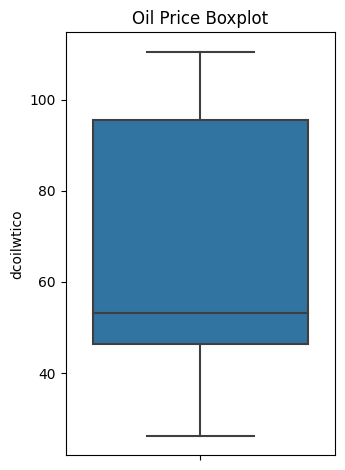

In [72]:
plt.subplot(1, 2, 2)
sns.boxplot(y=oil_price['dcoilwtico'])
plt.title('Oil Price Boxplot')
plt.ylabel('dcoilwtico')
plt.tight_layout()
plt.show()

The boxplot shows that the values are normally distributed with no significant outliers, and most prices range between 40 and 95 USD, indicating normal market fluctuations during this period.

Overall, the general trend of oil prices is downward over time.

In [73]:
oil_price['date'] = pd.to_datetime(oil_price['date'])

start_date = oil_price['date'].min()
end_date = oil_price['date'].max()

print(f"Start Date: {start_date}")
print(f"End Date:   {end_date}")


Start Date: 2013-01-01 00:00:00
End Date:   2017-08-31 00:00:00


# **Stores DataSet**

store_nbr: Unique ID for each store.


city: City where the store is located.


state: State or region of the store.


type: Store category (e.g., A, B, C) based on size or characteristics.


cluster: Group number indicating stores with similar sales patterns.



In [74]:
stores.columns.tolist()

['store_nbr', 'city', 'state', 'type', 'cluster']

In [75]:
stores.shape

(54, 5)

In [76]:
stores.head(10)

,store_nbr,city,state,type,cluster
0,1,Quito,Pichincha,D,13
1,2,Quito,Pichincha,D,13
2,3,Quito,Pichincha,D,8
3,4,Quito,Pichincha,D,9
4,5,Santo Domingo,Santo Domingo de los Tsachilas,D,4
5,6,Quito,Pichincha,D,13
6,7,Quito,Pichincha,D,8
7,8,Quito,Pichincha,D,8
8,9,Quito,Pichincha,B,6
9,10,Quito,Pichincha,C,15


In [77]:
stores.sample(15)

,store_nbr,city,state,type,cluster
7,8,Quito,Pichincha,D,8
50,51,Guayaquil,Guayas,A,17
34,35,Playas,Guayas,C,3
24,25,Salinas,Santa Elena,D,1
27,28,Guayaquil,Guayas,E,10
6,7,Quito,Pichincha,D,8
21,22,Puyo,Pastaza,C,7
11,12,Latacunga,Cotopaxi,C,15
49,50,Ambato,Tungurahua,A,14
40,41,Machala,El Oro,D,4


In [78]:
stores['city'] = stores['city'].str.strip().str.title()
stores['state'] = stores['state'].str.strip().str.title()
stores['type'] = stores['type'].str.strip().str.upper()

# Descriptive Statistics

In [79]:
stores.describe().T

,count,mean,std,min,25%,50%,75%,max
store_nbr,54.0,27.500000,15.732133,1.0,14.25,27.5,40.75,54.0
cluster,54.0,8.481481,4.693395,1.0,4.00,8.5,13.00,17.0


# Information about Stores DataSet

In [80]:
stores.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54 entries, 0 to 53
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   store_nbr  54 non-null     int64 
 1   city       54 non-null     object
 2   state      54 non-null     object
 3   type       54 non-null     object
 4   cluster    54 non-null     int64 
dtypes: int64(2), object(3)
memory usage: 2.2+ KB


In [81]:
stores.duplicated().sum()

0

In [82]:
stores.isna().sum()

store_nbr    0
city         0
state        0
type         0
cluster      0
dtype: int64

In [83]:
stores.nunique()

store_nbr    54
city         22
state        16
type          5
cluster      17
dtype: int64

In [84]:
print("Unique Cities :")
print("Count:", stores['city'].nunique())
print(stores['city'].unique())
print("\n")

Unique Cities :
Count: 22
['Quito' 'Santo Domingo' 'Cayambe' 'Latacunga' 'Riobamba' 'Ibarra'
 'Guaranda' 'Puyo' 'Ambato' 'Guayaquil' 'Salinas' 'Daule' 'Babahoyo'
 'Quevedo' 'Playas' 'Libertad' 'Cuenca' 'Loja' 'Machala' 'Esmeraldas'
 'Manta' 'El Carmen']




In [85]:
print(" Unique States :")
print("Count:", stores['state'].nunique())
print(stores['state'].unique())
print("\n")

 Unique States :
Count: 16
['Pichincha' 'Santo Domingo De Los Tsachilas' 'Cotopaxi' 'Chimborazo'
 'Imbabura' 'Bolivar' 'Pastaza' 'Tungurahua' 'Guayas' 'Santa Elena'
 'Los Rios' 'Azuay' 'Loja' 'El Oro' 'Esmeraldas' 'Manabi']




Type A: Large stores with high sales.

Type B: Medium-sized stores.

Type C: Small or local stores.

Type D / E: Very small or specialized stores.

In [86]:
print(" Unique Store Types :")
print("Count:", stores['type'].nunique())
print(stores['type'].unique())

 Unique Store Types :
Count: 5
['D' 'B' 'C' 'E' 'A']


# Distribution of Stores Types

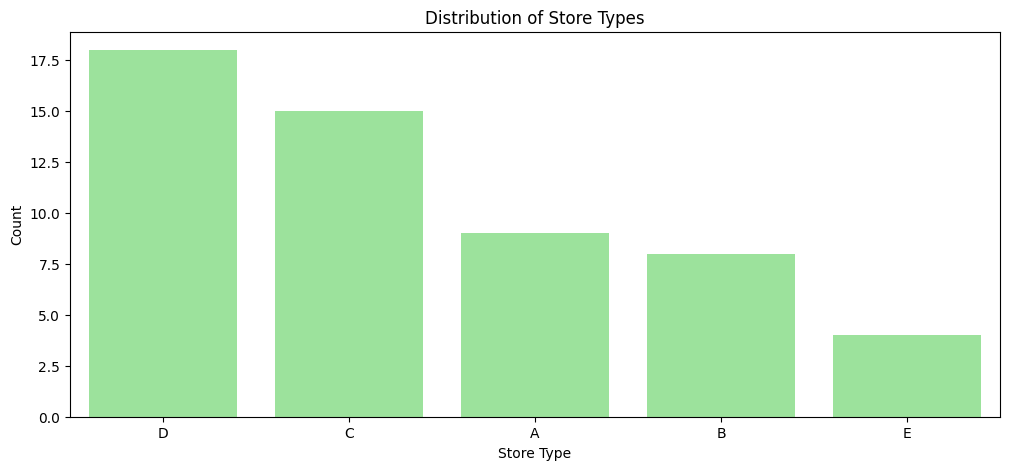

In [87]:
plt.figure(figsize=(12, 5))
sns.countplot(
    x='type',
    data=stores,
    order=stores['type'].value_counts().index,
    color='lightgreen'
)
plt.title('Distribution of Store Types')
plt.xlabel('Store Type')
plt.ylabel('Count')
plt.show()


# Number of Stores per State

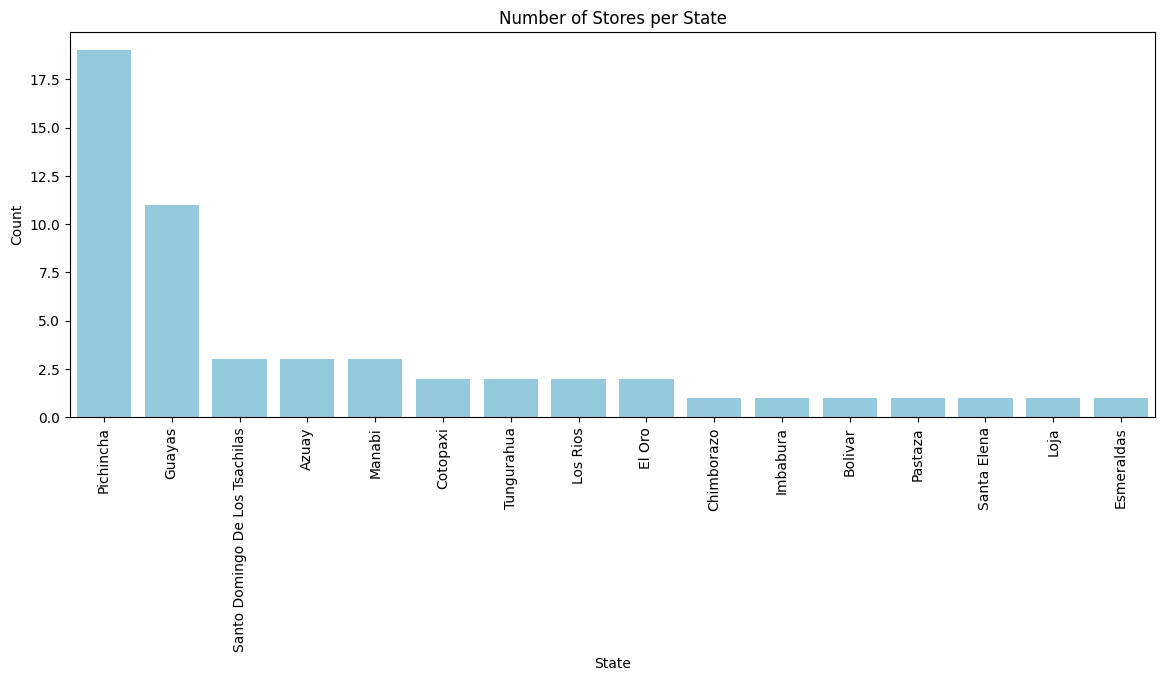

In [88]:
plt.figure(figsize=(14, 5))
sns.countplot(
    x='state',
    data=stores,
    order=stores['state'].value_counts().index,
    color='skyblue'
)
plt.title('Number of Stores per State')
plt.xlabel('State')
plt.ylabel('Count')
plt.xticks(rotation=90)
plt.show()


# ***Transactions DataSet***

date – The date when transactions were recorded.

store_nbr – Unique identifier of the store where the transactions occurred.

transactions – The total number of sales transactions made in that store on that specific date.

In [89]:
transactions.columns.tolist()

['date', 'store_nbr', 'transactions']

In [90]:
transactions.shape

(83488, 3)

In [91]:
transactions.head(10)

,date,store_nbr,transactions
0,2013-01-01,25,770
1,2013-01-02,1,2111
2,2013-01-02,2,2358
3,2013-01-02,3,3487
4,2013-01-02,4,1922
5,2013-01-02,5,1903
6,2013-01-02,6,2143
7,2013-01-02,7,1874
8,2013-01-02,8,3250
9,2013-01-02,9,2940


In [92]:
transactions.sample(15)

,date,store_nbr,transactions
3132,2013-03-11,4,1410
80322,2017-06-18,21,1611
7107,2013-06-04,48,2520
19123,2014-02-18,6,1633
73261,2017-02-06,15,1347
54516,2016-02-13,8,3202
54086,2016-02-05,2,2060
49950,2015-11-14,50,3032
81013,2017-07-01,10,1130
83200,2017-08-10,37,1523


# Descriptive Statistics

In [93]:
transactions.describe().T

,count,mean,std,min,25%,50%,75%,max
store_nbr,83488.0,26.939237,15.608204,1.0,13.0,27.0,40.0,54.0
transactions,83488.0,1694.602158,963.286644,5.0,1046.0,1393.0,2079.0,8359.0


# Information about Data

In [94]:
transactions.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 83488 entries, 0 to 83487
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   date          83488 non-null  object
 1   store_nbr     83488 non-null  int64 
 2   transactions  83488 non-null  int64 
dtypes: int64(2), object(1)
memory usage: 1.9+ MB


# Checking for Duplicates

In [95]:
transactions.duplicated().sum()

0

## Checking for Null Values

In [96]:
transactions.isna().sum()

date            0
store_nbr       0
transactions    0
dtype: int64

no null values in this dataset

In [97]:
transactions.describe().T

,count,mean,std,min,25%,50%,75%,max
store_nbr,83488.0,26.939237,15.608204,1.0,13.0,27.0,40.0,54.0
transactions,83488.0,1694.602158,963.286644,5.0,1046.0,1393.0,2079.0,8359.0


In [98]:
transactions.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 83488 entries, 0 to 83487
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   date          83488 non-null  object
 1   store_nbr     83488 non-null  int64 
 2   transactions  83488 non-null  int64 
dtypes: int64(2), object(1)
memory usage: 1.9+ MB


In [99]:
transactions.sample(10)

,date,store_nbr,transactions
81197,2017-07-04,32,582
71128,2016-12-27,3,3463
44455,2015-08-01,32,787
53242,2016-01-20,6,1859
31107,2014-10-30,43,1236
25573,2014-07-06,16,1176
43326,2015-07-10,10,894
13676,2013-10-23,12,1105
46283,2015-09-06,7,1581
67952,2016-10-26,17,1296


# Transactions over Time

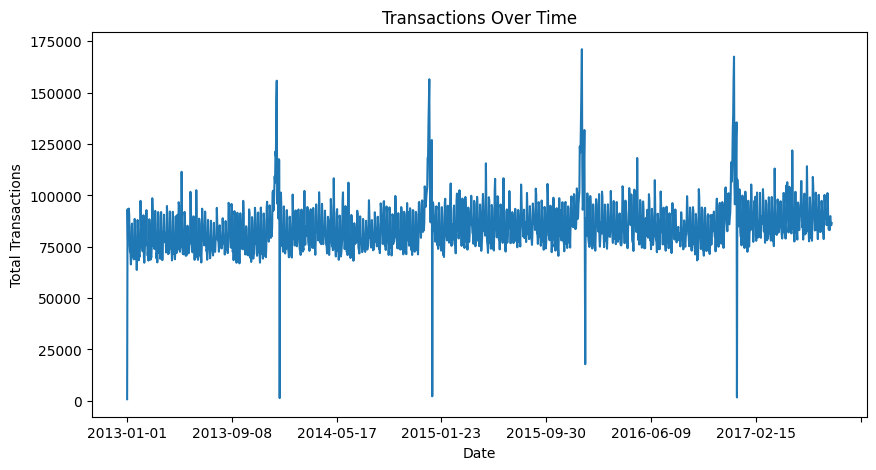

In [100]:
transactions.groupby('date')['transactions'].sum().plot(figsize=(10,5))
plt.title("Transactions Over Time")
plt.xlabel("Date")
plt.ylabel("Total Transactions")
plt.show()

# Monthly Transaction by Year

# Top 10 Stores by Total Transactions

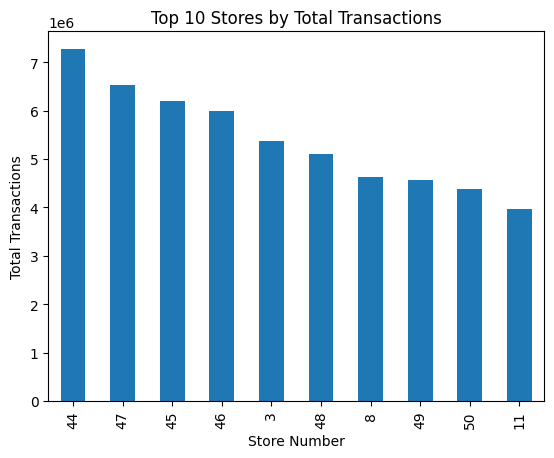

In [101]:
top_stores =transactions.groupby('store_nbr')['transactions'].sum().sort_values(ascending=False).head(10)
top_stores.plot(kind='bar')
plt.title("Top 10 Stores by Total Transactions")
plt.xlabel("Store Number")
plt.ylabel("Total Transactions")
plt.show()

In [102]:
transactions['date'] = pd.to_datetime(transactions['date'])

start_date = transactions['date'].min()
end_date = transactions['date'].max()

print(f" Data covers the period from {start_date.date()} to {end_date.date()}")

 Data covers the period from 2013-01-01 to 2017-08-15


# **Merging DataSets**

In [103]:
print(train.columns.tolist())
print(test.columns.tolist())
print(stores.columns.tolist())
print(oil_price.columns.tolist())
print(holidays.columns.tolist())
print(transactions.columns.tolist())

['id', 'date', 'store_nbr', 'family', 'sales', 'onpromotion']
['id', 'date', 'store_nbr', 'family', 'onpromotion']
['store_nbr', 'city', 'state', 'type', 'cluster']
['date', 'dcoilwtico']
['date', 'locale', 'locale_name', 'description', 'Holiday_Gen', 'Event_Gen', 'Work_Day_Gen']
['date', 'store_nbr', 'transactions']


In [104]:
print(f"   - Train: {train.shape}")
print(f"   - Test: {test.shape}")
print(f"   - Stores: {stores.shape}")
print(f"   - Oil: {oil_price.shape}")
print(f"   - Holidays: {holidays.shape}")
print(f"   - Transactions: {transactions.shape}")

   - Train: (3000888, 6)
   - Test: (28512, 5)
   - Stores: (54, 5)
   - Oil: (1218, 2)
   - Holidays: (338, 7)
   - Transactions: (83488, 3)


In [105]:
train['date'] = pd.to_datetime(train['date'])
test['date'] = pd.to_datetime(test['date'])
holidays['date'] = pd.to_datetime(holidays['date'])
oil_price['date'] = pd.to_datetime(oil_price['date'])
transactions['date'] = pd.to_datetime(transactions['date'])

In [106]:
# Initiating scaling instances
scalers = {'scaler_onpromotion' : MinMaxScaler(), 'scaler_day' : MinMaxScaler(), 'scaler_month' : MinMaxScaler(),
           'scaler_year' : MinMaxScaler(), 'scaler_dcoilwtico' : MinMaxScaler(), 'scaler_DoW' : MinMaxScaler()}

In [107]:
def process_data(data, stores, transactions, holidays, oil_price, fit_scaler, scalers):
    # Merge stores into data to substitute store ids with location data
    data = data.merge(stores, how='left', left_on='store_nbr', right_on='store_nbr')

    # Merge holidays into data to extend location names with location related holidays
    data = data.merge(holidays, how='left', left_on='date', right_on='date')
    data['Holiday'] = ((data['Holiday_Gen'] == True)
                       & ((data['city'] == data['locale_name'])
                          | (data['state'] == data['locale_name'])
                          | ('Ecuador' == data['locale_name']))).astype(dtype='float64')
    data['Event'] = ((data['Event_Gen'] == True)
                       & ((data['city'] == data['locale_name'])
                          | (data['state'] == data['locale_name'])
                          | ('Ecuador' == data['locale_name']))).astype(dtype='float64')
    data['Work_Day'] = ((data['Work_Day_Gen'] == True)
                        & ((data['city'] == data['locale_name'])
                           | (data['state'] == data['locale_name'])
                           | ('Ecuador' == data['locale_name']))).astype(dtype='float64')

    # Merge oil prices into data and interpolate missing values
    data = data.merge(oil_price, how='left', left_on='date', right_on='date')
    data.sort_values('id', inplace=True)
    data['dcoilwtico'] = data['dcoilwtico'].ffill()

    # Merge transactions into data
    data = data.merge(transactions, how='left', left_on=['date', 'store_nbr'], right_on=['date', 'store_nbr'])

    # Including day of week and pay day information
    data['date'] = pd.to_datetime(data['date'])
    data['day'] = data['date'].dt.day
    data['month'] = data['date'].dt.month
    data['year'] = data['date'].dt.year
    data['day_of_week'] = data['date'].dt.day_name()
    data['DoW'] = data['date'].dt.dayofweek
    data['Pay_Day'] = ((data['date'].dt.day == 1) | (data['date'].dt.day == 16)).astype(dtype='float64')
    data['Earthquake'] = (data['date'] == '2016-04-16').astype(dtype='float64')

    # Fill NaN values with proper substitute values
    data.fillna({'Holiday_Gen': False, 'Event_Gen': False, 'Work_Day_Gen': False, 'Holiday': 0.0, 'Event': 0.0,
                 'Work_Day': 0.0, 'Pay_Day': 0.0, 'Earthquake': 0.0, 'transactions': 0.0}, inplace=True)

    # One Hot Encoding of state related features
    encoder = OneHotEncoder()
    One_Hot_Coding = pd.DataFrame(encoder.fit_transform(data[['store_nbr', 'family', 'day_of_week']]).toarray(),
                                  columns=encoder.get_feature_names_out()) #.astype(dtype=np.int32) 'city', 'type', 'cluster',

    # Scaling numeric values
    if fit_scaler:
        scalers['scaler_dcoilwtico'].fit(oil_price[['dcoilwtico']])
        for col in ['onpromotion', 'day', 'month', 'year', 'DoW']:
            scalers[f'scaler_{col}'].fit(data[[col]])
    data[['dcoilwtico']] = scalers['scaler_dcoilwtico'].transform(data[['dcoilwtico']])
    for col in ['onpromotion', 'day', 'month', 'year', 'DoW']:
        data[[col]] = scalers[f'scaler_{col}'].transform(data[[col]])

    # Constructing feature vectors and labels vector
    features = data[['onpromotion', 'dcoilwtico', 'Holiday', 'Event', 'Work_Day', 'Earthquake', 'day', 'month', 'year']]
    features = features.merge(One_Hot_Coding, how='left', left_index=True, right_index=True)

    if 'sales' in data.columns:
        labels = data[['sales']]
    else: labels = []
    return features, labels, scalers, data

trainvaltes_feat, trainvaltes_label, scalers, datat = process_data(train, stores, transactions, holidays, oil_price, True, scalers)
test_feat, test_label, _, data = process_data(test, stores, transactions, holidays, oil_price, False, scalers)

In [108]:
data.columns

Index(['id', 'date', 'store_nbr', 'family', 'onpromotion', 'city', 'state',
       'type', 'cluster', 'locale', 'locale_name', 'description',
       'Holiday_Gen', 'Event_Gen', 'Work_Day_Gen', 'Holiday', 'Event',
       'Work_Day', 'dcoilwtico', 'transactions', 'day', 'month', 'year',
       'day_of_week', 'DoW', 'Pay_Day', 'Earthquake'],
      dtype='object')

In [109]:
train['date'] = pd.to_datetime(train['date'])
min_date = train['date'].min()
max_date = train['date'].max()
print("Date range:", min_date, "to", max_date)

Date range: 2013-01-01 00:00:00 to 2017-08-15 00:00:00


In [110]:
trainvaltes_feat.head()

,onpromotion,dcoilwtico,Holiday,Event,Work_Day,Earthquake,day,month,year,store_nbr_1,...,family_Produce,family_School And Office Supplies,family_Seafood,day_of_week_Friday,day_of_week_Monday,day_of_week_Saturday,day_of_week_Sunday,day_of_week_Thursday,day_of_week_Tuesday,day_of_week_Wednesday
0,0.0,0.792965,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1,0.0,0.792965,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2,0.0,0.792965,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
3,0.0,0.792965,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,0.0,0.792965,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [111]:
trainvaltes_feat.sample(5)

,onpromotion,dcoilwtico,Holiday,Event,Work_Day,Earthquake,day,month,year,store_nbr_1,...,family_Produce,family_School And Office Supplies,family_Seafood,day_of_week_Friday,day_of_week_Monday,day_of_week_Saturday,day_of_week_Sunday,day_of_week_Thursday,day_of_week_Tuesday,day_of_week_Wednesday
2968868,0.000000,0.234869,0.0,0.0,0.0,0.0,0.966667,0.454545,1.00,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
1585282,0.000000,0.403411,0.0,0.0,0.0,0.0,1.000000,0.363636,0.50,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2075175,0.018893,0.064669,0.0,0.0,0.0,0.0,0.866667,0.090909,0.75,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
1633992,0.000000,0.395594,0.0,0.0,0.0,0.0,0.800000,0.454545,0.50,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
714062,0.000000,0.845197,0.0,0.0,0.0,0.0,0.000000,0.090909,0.25,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0


In [112]:
print(trainvaltes_feat.columns.tolist())

['onpromotion', 'dcoilwtico', 'Holiday', 'Event', 'Work_Day', 'Earthquake', 'day', 'month', 'year', 'store_nbr_1', 'store_nbr_2', 'store_nbr_3', 'store_nbr_4', 'store_nbr_5', 'store_nbr_6', 'store_nbr_7', 'store_nbr_8', 'store_nbr_9', 'store_nbr_10', 'store_nbr_11', 'store_nbr_12', 'store_nbr_13', 'store_nbr_14', 'store_nbr_15', 'store_nbr_16', 'store_nbr_17', 'store_nbr_18', 'store_nbr_19', 'store_nbr_20', 'store_nbr_21', 'store_nbr_22', 'store_nbr_23', 'store_nbr_24', 'store_nbr_25', 'store_nbr_26', 'store_nbr_27', 'store_nbr_28', 'store_nbr_29', 'store_nbr_30', 'store_nbr_31', 'store_nbr_32', 'store_nbr_33', 'store_nbr_34', 'store_nbr_35', 'store_nbr_36', 'store_nbr_37', 'store_nbr_38', 'store_nbr_39', 'store_nbr_40', 'store_nbr_41', 'store_nbr_42', 'store_nbr_43', 'store_nbr_44', 'store_nbr_45', 'store_nbr_46', 'store_nbr_47', 'store_nbr_48', 'store_nbr_49', 'store_nbr_50', 'store_nbr_51', 'store_nbr_52', 'store_nbr_53', 'store_nbr_54', 'family_Automotive', 'family_Baby Care', 'fam

In [113]:
trainvaltes_feat.shape

(3054348, 103)

In [114]:
trainvaltes_feat.isna().sum()

onpromotion              0
dcoilwtico               0
Holiday                  0
Event                    0
Work_Day                 0
                        ..
day_of_week_Saturday     0
day_of_week_Sunday       0
day_of_week_Thursday     0
day_of_week_Tuesday      0
day_of_week_Wednesday    0
Length: 103, dtype: int64

In [115]:
trainvaltes_feat.duplicated().sum()

30756

In [116]:
trainvaltes_feat.drop_duplicates(inplace=True)

In [117]:
trainvaltes_label = trainvaltes_label.reset_index(drop=True)

In [118]:
trainvaltes_feat.duplicated().sum()

0

In [119]:
eda_train= pd.concat([trainvaltes_feat, trainvaltes_label], axis=1)
threshold_high = eda_train['sales'].quantile(0.99)
outliers = eda_train[eda_train['sales'] > threshold_high].sort_values('sales', ascending=False)

In [120]:
eda_train = pd.concat([trainvaltes_feat, trainvaltes_label, datat['date']], axis=1)

Q1 = eda_train['sales'].quantile(0.25)
Q3 = eda_train['sales'].quantile(0.75)
IQR = Q3 - Q1

outlier_mask = eda_train['sales'] > (Q3 + 1.5*IQR)
outliers = eda_train[outlier_mask]

important_cols = ['date', 'sales', 'onpromotion', 'Holiday', 'Event', 'Earthquake', 'Work_Day']

outlier_summary = outliers[important_cols].sort_values(by='sales', ascending=False)
outlier_summary.reset_index(drop=True, inplace=True)
outlier_summary


,date,sales,onpromotion,Holiday,Event,Earthquake,Work_Day
0,2016-05-02,124717.000,0.079622,0.0,1.0,0.0,0.0
1,2016-10-07,89576.360,0.000000,0.0,0.0,0.0,0.0
2,2016-04-21,87438.516,0.071525,0.0,1.0,0.0,0.0
3,2016-04-21,87438.516,0.071525,0.0,0.0,0.0,0.0
4,2016-04-18,76090.000,0.051282,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...
455501,2014-01-23,490.054,0.000000,0.0,0.0,0.0,0.0
455502,2015-04-12,490.052,0.000000,0.0,0.0,0.0,0.0
455503,2016-03-18,490.044,0.002699,0.0,0.0,0.0,0.0
455504,2015-12-04,490.038,0.006748,0.0,0.0,0.0,0.0


In [121]:
print(eda_train.columns.tolist())

['onpromotion', 'dcoilwtico', 'Holiday', 'Event', 'Work_Day', 'Earthquake', 'day', 'month', 'year', 'store_nbr_1', 'store_nbr_2', 'store_nbr_3', 'store_nbr_4', 'store_nbr_5', 'store_nbr_6', 'store_nbr_7', 'store_nbr_8', 'store_nbr_9', 'store_nbr_10', 'store_nbr_11', 'store_nbr_12', 'store_nbr_13', 'store_nbr_14', 'store_nbr_15', 'store_nbr_16', 'store_nbr_17', 'store_nbr_18', 'store_nbr_19', 'store_nbr_20', 'store_nbr_21', 'store_nbr_22', 'store_nbr_23', 'store_nbr_24', 'store_nbr_25', 'store_nbr_26', 'store_nbr_27', 'store_nbr_28', 'store_nbr_29', 'store_nbr_30', 'store_nbr_31', 'store_nbr_32', 'store_nbr_33', 'store_nbr_34', 'store_nbr_35', 'store_nbr_36', 'store_nbr_37', 'store_nbr_38', 'store_nbr_39', 'store_nbr_40', 'store_nbr_41', 'store_nbr_42', 'store_nbr_43', 'store_nbr_44', 'store_nbr_45', 'store_nbr_46', 'store_nbr_47', 'store_nbr_48', 'store_nbr_49', 'store_nbr_50', 'store_nbr_51', 'store_nbr_52', 'store_nbr_53', 'store_nbr_54', 'family_Automotive', 'family_Baby Care', 'fam

# Outliers Analysis

In [122]:
print("OUTLIER STATISTICS : ")
print(f"Total outliers: {len(outliers)}")
print(f"Percentage of data: {len(outliers)/len(eda_train)*100:.2f}%")
print(f"\nSales Statistics:")
print(f"Min outlier sales: {outliers['sales'].min():.2f}")
print(f"Max outlier sales: {outliers['sales'].max():.2f}")
print(f"Mean outlier sales: {outliers['sales'].mean():.2f}")
print(f"Median outlier sales: {outliers['sales'].median():.2f}")

OUTLIER STATISTICS : 
Total outliers: 455506
Percentage of data: 14.91%

Sales Statistics:
Min outlier sales: 490.03
Max outlier sales: 124717.00
Mean outlier sales: 2071.34
Median outlier sales: 1254.00


In [123]:
print("OUTLIERS BY PRODUCT FAMILY : ")
family_cols = [col for col in eda_train.columns if col.startswith('family_')]
outliers_families = outliers[family_cols + ['sales']].copy()
outliers_families['active_family'] = outliers_families[family_cols].idxmax(axis=1)
outliers_families['active_family'] = outliers_families['active_family'].str.replace('family_', '')
family_analysis = outliers_families.groupby('active_family').agg({
    'sales': ['count', 'mean', 'max', 'sum']
}).round(2)
family_analysis.columns = ['Count', 'Avg_Sales', 'Max_Sales', 'Total_Sales']
family_analysis = family_analysis.sort_values('Count', ascending=False)
print("\nTop 10 Families with Most Outliers:")
print(family_analysis.head(10))


OUTLIERS BY PRODUCT FAMILY : 

Top 10 Families with Most Outliers:
               Count  Avg_Sales  Max_Sales   Total_Sales
active_family                                           
Grocery I      84242    4119.98  124717.00  3.470754e+08
Beverages      79918    2720.63   25413.00  2.174276e+08
Cleaning       76372    1248.82   11377.00  9.537509e+07
Dairy          48284    1136.50    5636.00  5.487470e+07
Produce        43667    2767.58   17850.62  1.208520e+08
Bread/Bakery   36600     814.03    4551.30  2.979363e+07
Poultry        21295     931.86   12143.20  1.984387e+07
Meats          20909     853.83   89576.36  1.785283e+07
Deli           10644     714.25    2118.32  7.602439e+06
Personal Care  10543     743.86    7504.00  7.842503e+06


In [124]:
print("OUTLIERS BY STORE :")
store_cols = [col for col in eda_train.columns if col.startswith('store_nbr_')]
outliers_stores = outliers[store_cols + ['sales']].copy()
outliers_stores['active_store'] = outliers_stores[store_cols].idxmax(axis=1)
outliers_stores['active_store'] = outliers_stores['active_store'].str.replace('store_nbr_', '')
store_analysis = outliers_stores.groupby('active_store').agg({
    'sales': ['count', 'mean', 'max']
}).round(2)
store_analysis.columns = ['Count', 'Avg_Sales', 'Max_Sales']
store_analysis = store_analysis.sort_values('Count', ascending=False)
print("\nTop 10 Stores with Most Outliers:")
print(store_analysis.head(10))


OUTLIERS BY STORE :

Top 10 Stores with Most Outliers:
              Count  Avg_Sales  Max_Sales
active_store                             
44            18307    3259.88   46271.00
45            16858    3089.73   76090.00
47            16621    2927.39   23024.00
46            16125    2485.45   25238.00
3             15753    3010.24   21858.00
48            14921    2274.32   22255.00
49            14200    2834.68   21190.00
51            12550    2380.50   14179.00
50            12312    2090.48   14431.00
11            12153    2136.04   20891.56


In [125]:
print("OUTLIERS VS SPECIAL EVENTS  :")
event_analysis = pd.DataFrame({
    'Feature': ['Holiday', 'Event', 'Earthquake', 'Work_Day', 'onpromotion'],
    'Outliers_Pct': [
        outliers['Holiday'].mean() * 100,
        outliers['Event'].mean() * 100,
        outliers['Earthquake'].mean() * 100,
        outliers['Work_Day'].mean() * 100,
        outliers['onpromotion'].mean()
    ],
    'Normal_Pct': [
        eda_train[~outlier_mask]['Holiday'].mean() * 100,
        eda_train[~outlier_mask]['Event'].mean() * 100,
        eda_train[~outlier_mask]['Earthquake'].mean() * 100,
        eda_train[~outlier_mask]['Work_Day'].mean() * 100,
        eda_train[~outlier_mask]['onpromotion'].mean()
    ]
})
event_analysis['Difference'] = event_analysis['Outliers_Pct'] - event_analysis['Normal_Pct']
print(event_analysis.round(2))


OUTLIERS VS SPECIAL EVENTS  :
       Feature  Outliers_Pct  Normal_Pct  Difference
0      Holiday          5.51        4.93        0.58
1        Event          3.60        3.18        0.43
2   Earthquake          0.07        0.06        0.02
3     Work_Day          0.30        0.29        0.01
4  onpromotion          0.02        0.00        0.02


In [126]:
print("TEMPORAL ANALYSIS  :")
print("\nOutliers by Month:")
month_analysis = outliers.groupby('month').agg({
    'sales': ['count', 'mean']
}).round(2)
month_analysis.columns = ['Count', 'Avg_Sales']
print(month_analysis.sort_values('Count', ascending=False))

print("\nOutliers by Day of Week:")
dow_cols = [col for col in eda_train.columns if col.startswith('day_of_week_')]
outliers_dow = outliers[dow_cols + ['sales']].copy()
outliers_dow['active_dow'] = outliers_dow[dow_cols].idxmax(axis=1)
outliers_dow['active_dow'] = outliers_dow['active_dow'].str.replace('day_of_week_', '')
dow_analysis = outliers_dow.groupby('active_dow')['sales'].agg(['count', 'mean']).round(2)
dow_analysis.columns = ['Count', 'Avg_Sales']
print(dow_analysis.sort_values('Count', ascending=False))


TEMPORAL ANALYSIS  :

Outliers by Month:
          Count  Avg_Sales
month                     
0.545455  42863    2078.79
0.363636  41128    2035.08
0.181818  40680    2052.56
0.454545  40014    2035.99
0.000000  39495    2057.26
1.000000  38706    2304.09
0.272727  38602    2055.86
0.636364  35985    1975.21
0.090909  35249    1945.21
0.909091  32929    2130.82
0.818182  32864    2092.84
0.727273  32055    2080.09

Outliers by Day of Week:
            Count  Avg_Sales
active_dow                  
Sunday      74513    2414.91
Saturday    73178    2255.41
Monday      64086    2006.56
Friday      61650    1915.87
Tuesday     60882    1932.41
Wednesday   59775    2033.83
Thursday    56486    1804.23


In [127]:
print("TOP 20 EXTREME OUTLIERS  :")
top_outliers = outliers.nlargest(20, 'sales').copy()
top_outliers['store'] = top_outliers[store_cols].idxmax(axis=1).str.replace('store_nbr_', '')
top_outliers['family'] = top_outliers[family_cols].idxmax(axis=1).str.replace('family_', '')
display_cols = ['date', 'sales', 'store', 'family', 'onpromotion', 
                'Holiday', 'Event', 'Earthquake', 'Work_Day', 'month', 'year']
print(top_outliers[display_cols].to_string(index=False))


TOP 20 EXTREME OUTLIERS  :
      date      sales store    family  onpromotion  Holiday  Event  Earthquake  Work_Day    month  year
2016-05-02 124717.000     2 Grocery I     0.079622      0.0    1.0         0.0       0.0 0.363636  0.75
2016-10-07  89576.360    39     Meats     0.000000      0.0    0.0         0.0       0.0 0.818182  0.75
2016-04-21  87438.516    20 Grocery I     0.071525      0.0    0.0         0.0       0.0 0.272727  0.75
2016-04-21  87438.516    20 Grocery I     0.071525      0.0    1.0         0.0       0.0 0.272727  0.75
2016-04-18  76090.000    45 Grocery I     0.051282      0.0    1.0         0.0       0.0 0.272727  0.75
2016-04-26  63434.000     2 Grocery I     0.040486      0.0    1.0         0.0       0.0 0.272727  0.75
2016-04-21  53874.000    45 Grocery I     0.059379      0.0    1.0         0.0       0.0 0.272727  0.75
2016-04-21  53874.000    45 Grocery I     0.059379      0.0    0.0         0.0       0.0 0.272727  0.75
2013-11-12  46271.000    44 Grocery I

In [128]:
print("FEATURE CORRELATION WITH OUTLIER SALES  :")
numeric_features = ['onpromotion', 'dcoilwtico', 'Holiday', 'Event', 
                    'Work_Day', 'Earthquake', 'month', 'year']
correlations = outliers[numeric_features + ['sales']].corr()['sales'].drop('sales').sort_values(ascending=False)
print(correlations)



FEATURE CORRELATION WITH OUTLIER SALES  :
onpromotion    0.291515
year           0.093710
month          0.025906
Holiday        0.023992
Event          0.015778
Earthquake     0.002622
Work_Day       0.001468
dcoilwtico    -0.085925
Name: sales, dtype: float64


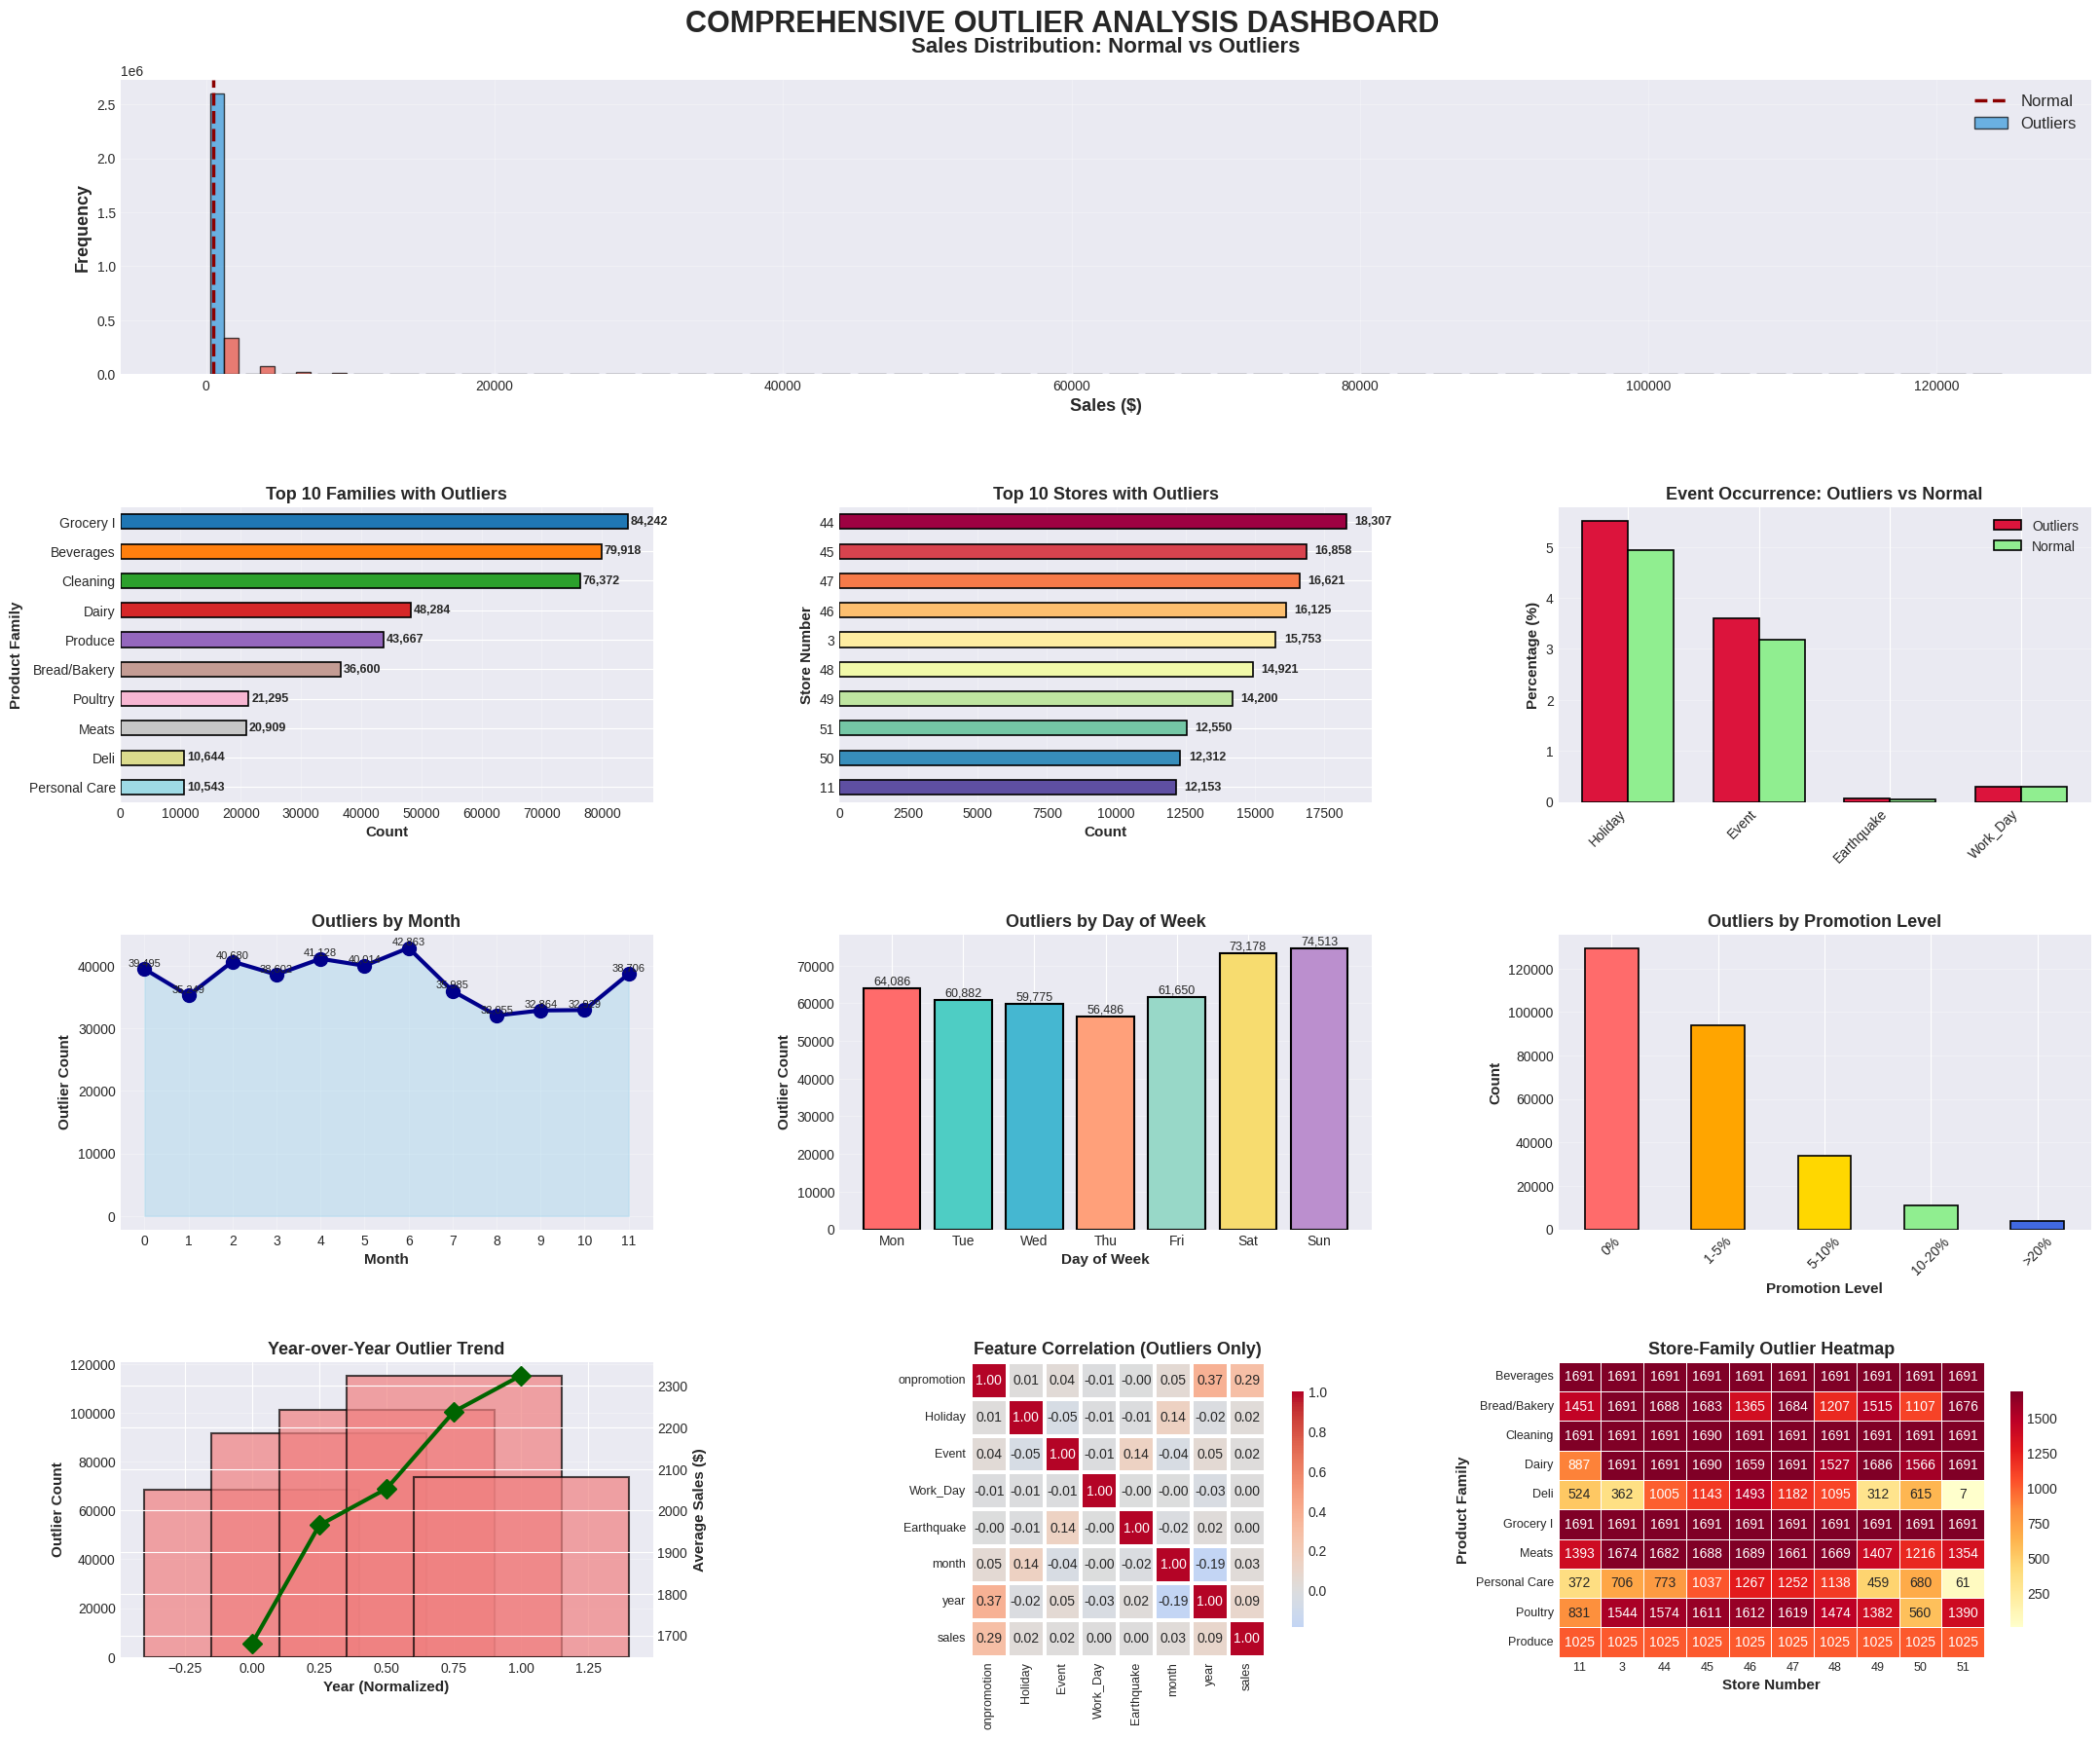

In [137]:
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

fig = plt.figure(figsize=(22, 18))
gs = fig.add_gridspec(4, 3, hspace=0.45, wspace=0.35, top=0.94, bottom=0.04, left=0.06, right=0.98)

ax1 = fig.add_subplot(gs[0, :])
normal_data = eda_train[~outlier_mask]['sales']
outlier_data = outliers['sales']

ax1.hist([normal_data, outlier_data], bins=50, alpha=0.7, edgecolor='black', color=['#3498db', '#e74c3c'])
ax1.set_xlabel('Sales ($)', fontsize=13, fontweight='bold')
ax1.set_ylabel('Frequency', fontsize=13, fontweight='bold')
ax1.set_title('Sales Distribution: Normal vs Outliers', fontsize=16, fontweight='bold', pad=20)
ax1.axvline(Q3 + 1.5*IQR, color='darkred', linestyle='--', linewidth=2.5)
ax1.legend(['Normal', 'Outliers'], fontsize=12, loc='upper right')
ax1.grid(True, alpha=0.3)

ax2 = fig.add_subplot(gs[1, 0])
family_cols = [col for col in eda_train.columns if col.startswith('family_')]
outliers_families = outliers[family_cols + ['sales']].copy()
outliers_families['active_family'] = outliers_families[family_cols].idxmax(axis=1).str.replace('family_', '')
family_counts = outliers_families['active_family'].value_counts().head(10)
colors_family = plt.cm.tab20(np.linspace(0, 1, 10))
family_counts.plot(kind='barh', ax=ax2, edgecolor='black', linewidth=1.2, color=colors_family)
ax2.set_xlabel('Count', fontsize=11, fontweight='bold')
ax2.set_ylabel('Product Family', fontsize=11, fontweight='bold')
ax2.set_title('Top 10 Families with Outliers', fontsize=13, fontweight='bold')
ax2.invert_yaxis()
ax2.grid(axis='x', alpha=0.3)
for i, v in enumerate(family_counts.values):
    ax2.text(v + 500, i, f'{v:,}', va='center', fontweight='bold', fontsize=9)

ax3 = fig.add_subplot(gs[1, 1])
store_cols = [col for col in eda_train.columns if col.startswith('store_nbr_')]
outliers_stores = outliers[store_cols + ['sales']].copy()
outliers_stores['active_store'] = outliers_stores[store_cols].idxmax(axis=1).str.replace('store_nbr_', '')
store_counts = outliers_stores['active_store'].value_counts().head(10)
colors_store = plt.cm.Spectral(np.linspace(0, 1, 10))
store_counts.plot(kind='barh', ax=ax3, edgecolor='black', linewidth=1.2, color=colors_store)
ax3.set_xlabel('Count', fontsize=11, fontweight='bold')
ax3.set_ylabel('Store Number', fontsize=11, fontweight='bold')
ax3.set_title('Top 10 Stores with Outliers', fontsize=13, fontweight='bold')
ax3.invert_yaxis()
ax3.grid(axis='x', alpha=0.3)
for i, v in enumerate(store_counts.values):
    ax3.text(v + 300, i, f'{v:,}', va='center', fontweight='bold', fontsize=9)

ax4 = fig.add_subplot(gs[1, 2])
event_features = ['Holiday', 'Event', 'Earthquake', 'Work_Day']
outlier_event_pct = [outliers[feat].mean() * 100 for feat in event_features]
normal_event_pct = [eda_train[~outlier_mask][feat].mean() * 100 for feat in event_features]
x = np.arange(len(event_features))
width = 0.35
ax4.bar(x - width/2, outlier_event_pct, width, color='crimson', edgecolor='black', linewidth=1.2)
ax4.bar(x + width/2, normal_event_pct, width, color='lightgreen', edgecolor='black', linewidth=1.2)
ax4.set_ylabel('Percentage (%)', fontsize=11, fontweight='bold')
ax4.set_title('Event Occurrence: Outliers vs Normal', fontsize=13, fontweight='bold')
ax4.set_xticks(x)
ax4.set_xticklabels(event_features, rotation=45, ha='right', fontsize=10)
ax4.legend(['Outliers','Normal'], fontsize=10)
ax4.grid(axis='y', alpha=0.3)

ax5 = fig.add_subplot(gs[2, 0])
month_counts = outliers.groupby('month').size().sort_index()
ax5.plot(range(len(month_counts)), month_counts.values, marker='o', linewidth=3, markersize=10, color='darkblue')
ax5.fill_between(range(len(month_counts)), month_counts.values, alpha=0.3, color='skyblue')
ax5.set_xlabel('Month', fontsize=11, fontweight='bold')
ax5.set_ylabel('Outlier Count', fontsize=11, fontweight='bold')
ax5.set_title('Outliers by Month', fontsize=13, fontweight='bold')
ax5.set_xticks(range(len(month_counts)))
ax5.grid(True, alpha=0.3)
for i, v in enumerate(month_counts.values):
    ax5.text(i, v + 500, f'{v:,}', ha='center', fontsize=8)

ax6 = fig.add_subplot(gs[2, 1])
dow_cols = [col for col in eda_train.columns if col.startswith('day_of_week_')]
outliers_dow = outliers[dow_cols + ['sales']].copy()
outliers_dow['active_dow'] = outliers_dow[dow_cols].idxmax(axis=1).str.replace('day_of_week_', '')
dow_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
dow_counts = outliers_dow['active_dow'].value_counts().reindex(dow_order, fill_value=0)
colors_dow = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A', '#98D8C8', '#F7DC6F', '#BB8FCE']
bars = ax6.bar(range(len(dow_counts)), dow_counts.values, color=colors_dow, edgecolor='black', linewidth=1.5)
ax6.set_xlabel('Day of Week', fontsize=11, fontweight='bold')
ax6.set_ylabel('Outlier Count', fontsize=11, fontweight='bold')
ax6.set_title('Outliers by Day of Week', fontsize=13, fontweight='bold')
ax6.set_xticks(range(len(dow_counts)))
ax6.set_xticklabels([d[:3] for d in dow_order], fontsize=10)
ax6.grid(axis='y', alpha=0.3)
for i, (bar, v) in enumerate(zip(bars, dow_counts.values)):
    ax6.text(bar.get_x() + bar.get_width()/2, v + 1000, f'{v:,}', ha='center', fontsize=9)

ax7 = fig.add_subplot(gs[2, 2])
promotion_bins = [0, 0.01, 0.05, 0.1, 0.2, 1.0]
promotion_labels = ['0%', '1-5%', '5-10%', '10-20%', '>20%']
outliers_copy = outliers.copy()
outliers_copy['promo_category'] = pd.cut(outliers_copy['onpromotion'], bins=promotion_bins, labels=promotion_labels)
promo_analysis = outliers_copy.groupby('promo_category')['sales'].agg(['count', 'mean'])
colors_promo = ['#FF6B6B', '#FFA500', '#FFD700', '#90EE90', '#4169E1']
promo_analysis['count'].plot(kind='bar', ax=ax7, edgecolor='black', linewidth=1.2, rot=45, color=colors_promo)
ax7.set_xlabel('Promotion Level', fontsize=11, fontweight='bold')
ax7.set_ylabel('Count', fontsize=11, fontweight='bold')
ax7.set_title('Outliers by Promotion Level', fontsize=13, fontweight='bold')
ax7.grid(axis='y', alpha=0.3)

ax8 = fig.add_subplot(gs[3, 0])
year_analysis = outliers.groupby('year').agg({'sales': ['count', 'mean']})
year_analysis.columns = ['count', 'mean']
ax8_twin = ax8.twinx()
ax8.bar(year_analysis.index, year_analysis['count'], alpha=0.7, color='lightcoral', edgecolor='black', linewidth=1.5)
ax8_twin.plot(year_analysis.index, year_analysis['mean'], marker='D', linewidth=3, markersize=10, color='darkgreen')
ax8.set_xlabel('Year (Normalized)', fontsize=11, fontweight='bold')
ax8.set_ylabel('Outlier Count', fontsize=11, fontweight='bold')
ax8_twin.set_ylabel('Average Sales ($)', fontsize=11, fontweight='bold')
ax8.set_title('Year-over-Year Outlier Trend', fontsize=13, fontweight='bold')
ax8.grid(axis='y', alpha=0.3)

ax9 = fig.add_subplot(gs[3, 1])
numeric_features = ['onpromotion', 'Holiday', 'Event', 'Work_Day', 'Earthquake', 'month', 'year', 'sales']
corr_matrix = outliers[numeric_features].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True, linewidths=1.5, cbar_kws={"shrink": 0.8}, ax=ax9)
ax9.set_title('Feature Correlation (Outliers Only)', fontsize=13, fontweight='bold')
ax9.tick_params(axis='both', labelsize=9)

ax10 = fig.add_subplot(gs[3, 2])
outliers_combined = outliers.copy()
outliers_combined['store'] = outliers_stores['active_store']
outliers_combined['family'] = outliers_families['active_family']
top_stores = outliers_combined['store'].value_counts().head(10).index
top_families = outliers_combined['family'].value_counts().head(10).index
heatmap_data = outliers_combined[outliers_combined['store'].isin(top_stores) & outliers_combined['family'].isin(top_families)]
pivot_table = heatmap_data.pivot_table(values='sales', index='family', columns='store', aggfunc='count', fill_value=0)
sns.heatmap(pivot_table, cmap='YlOrRd', annot=True, fmt='g', cbar_kws={"shrink": 0.8}, ax=ax10, linewidths=0.5)
ax10.set_title('Store-Family Outlier Heatmap', fontsize=13, fontweight='bold')
ax10.set_xlabel('Store Number', fontsize=11, fontweight='bold')
ax10.set_ylabel('Product Family', fontsize=11, fontweight='bold')
ax10.tick_params(axis='both', labelsize=9)

fig.suptitle('COMPREHENSIVE OUTLIER ANALYSIS DASHBOARD', fontsize=22, fontweight='bold', y=0.98)
plt.show()


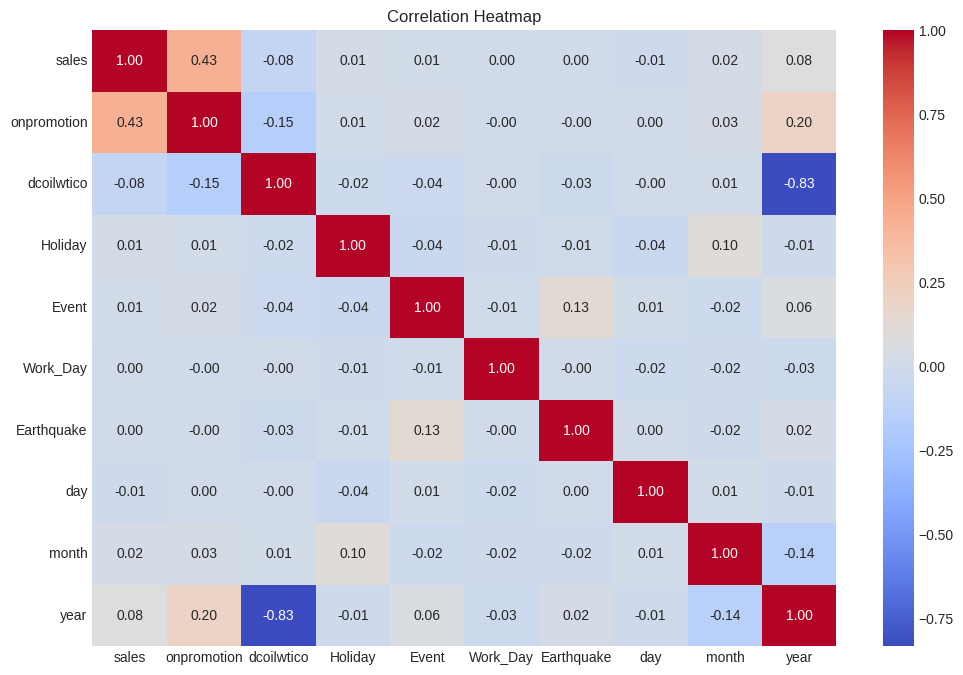

In [131]:
numeric_cols = [
    'sales',
    'onpromotion',
    'dcoilwtico',
    'Holiday',
    'Event',
    'Work_Day',
    'Earthquake',
    'day',
    'month',
    'year'
]

plt.figure(figsize=(12,8))
sns.heatmap(eda_train[numeric_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

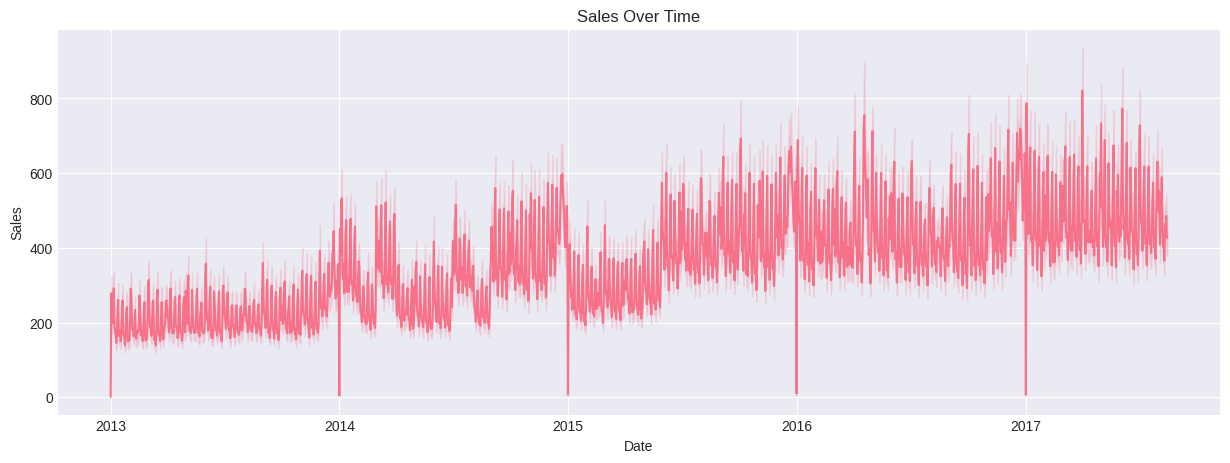

In [132]:
plt.figure(figsize=(15,5))
sns.lineplot(data=eda_train, x='date', y='sales')
plt.title("Sales Over Time")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.show()

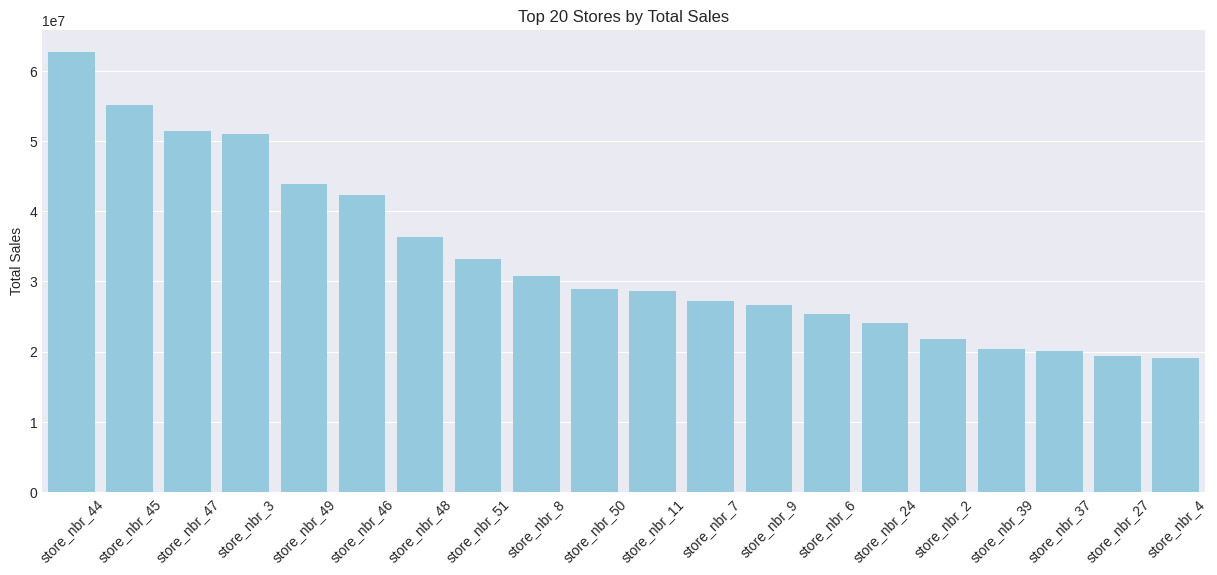

In [133]:
store_cols = [c for c in eda_train.columns if c.startswith('store_nbr_')]
store_sales = eda_train[store_cols].multiply(eda_train['sales'], axis=0).sum().sort_values(ascending=False).head(20)

plt.figure(figsize=(15,6))
sns.barplot(x=store_sales.index, y=store_sales.values, color="skyblue")
plt.xticks(rotation=45)
plt.title("Top 20 Stores by Total Sales")
plt.ylabel("Total Sales")
plt.show()


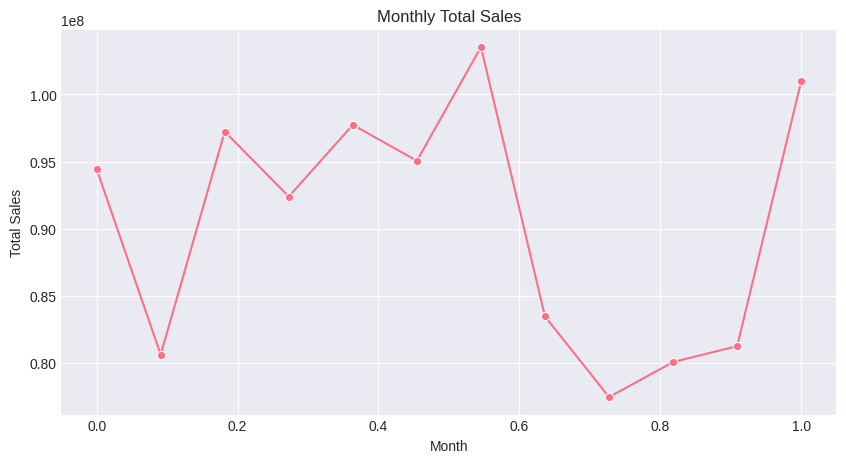

In [134]:
monthly_sales = eda_train.groupby('month')['sales'].sum()
plt.figure(figsize=(10,5))
sns.lineplot(x=monthly_sales.index, y=monthly_sales.values, marker='o')
plt.title("Monthly Total Sales")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.show()

# Spliting DataSets

In [135]:
from sklearn.model_selection import StratifiedGroupKFold

In [138]:
## Spliting the train data into train, val and tes

from sklearn.model_selection import StratifiedGroupKFold
import numpy as np

datat = datat.loc[trainvaltes_feat.index]

skf20 = StratifiedGroupKFold(n_splits=20, shuffle=True, random_state=2023)

for fold, (train_idx, val_idx) in enumerate(
            skf20.split(trainvaltes_feat,
                        datat['store_nbr'],
                        datat['date'])):

    train_feat = trainvaltes_feat.iloc[train_idx]
    val_feat   = trainvaltes_feat.iloc[val_idx]

    train_label = trainvaltes_label.iloc[train_idx]
    val_label   = trainvaltes_label.iloc[val_idx]

    print(f"Fold {fold}: Train {len(train_feat)} | Val {len(val_feat)}")
    break

print(len(train_feat), len(val_feat))


Fold 0: Train 2875686 | Val 147906
2875686 147906
